





























# Homework 2: Multiclass Classification and Kernel Methods
**Submission Deadline: June 5, 2026, Friday, 9:30**

---

> **Machine Learning - Foundations and Algorithms** in Summer Semester 2026
>
> - Prof. Gerhard Neumann
> - Instructors for this exercise: Florian Seligmann (florian.seligmann@kit.edu), and Emiliyan Gospodinov (emiliyan.gospodinov@kit.edu)
> 
> ⚠️ For general questions about the exercises, please post in the Ilias forum so we can answer them once for all students. Only use email for individual questions whose answers are not relevant to all students.

---

## Homework Info

This exercise is about simple (probabilistic) methods for regression and classification.
For regression, you will implement ridge regression, and for classification a generative naive Bayes classifier and a discriminative logistic regression model.

This homework contains both theory tasks and coding tasks. **Only the coding and multiple-choice tasks will be graded, all other tasks are marked with "(Not Graded)".** We still recommend to complete the theory tasks as they will prepare you for the exam, and we will discuss them in the exercise session.

## Group Submission

- The exercise sheets can be submitted in **groups of up to 3 students**.
- **Each person in the group must upload the edited notebook to Ilias**. It is not sufficient if only one person from the group does this. If you forgot to upload but at least on other group member upholds his solution, you will receive 2/3 of the points the **first** time this happens, and zero points if it **happens again**.
- **The submission deadline is strict**. Late submissions receive zero points. **We do not accept submissions via e-mail**. 
- It is possible to join a new group during the semester if your own group dissolves early. Each group must upload their own solution, and we will check submissions for duplicates.
- You can use the team building forum (https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&cmdNode=xs:lz:5y&cmdClass=ilBookingObjectGUI&ref_id=2930523) to team up. If you already have group members or want to submit alone, you do not need to use the forum.


Groups are automatically recorded for each exercise, so **please enter the u-identifiers of your group members in the *next* cell.** If your group consists of only 2 students or if you are submitting alone, leave the remaining fields empty.

Here is an **example** for a group consisting of uabcd and uefgh:

_U-identifiers of group members:_

_Member 1: uabcd_

_Member 2: uefgh_

_Member 3:_

Enter your group members in the *next* cell!

U-identifiers of group members:

Member 1: uiwkc

Member 2: urelg

Member 3:

## Auto-grading

We use an auto-grading system that automatically analyzes your submitted Jupyter Notebooks and checks them for correctness using hidden tests. These tests determine the points you receive for the exercise sheet.

To ensure auto-grading works smoothly, please note the following:

- The notebook must have the filename "ex_02_multiclass_classification_kernel_methods.ipynb"
- **Upload only the Jupyter Notebook** on Ilias as a single file (not as a zip!). **Do not include any additional files**.
- Before submitting a notebook, test that everything runs without errors from start to finish.
- **Cells marked with "##### DO NOT CHANGE #####" must not be edited or deleted**
  - There may be seemingly empty cells that are also marked with "##### DO NOT CHANGE #####". These must also not be edited or deleted.
  - If you do modify them, auto-grading will not work and you will receive no points.
  - We will be strict about this and make no exceptions if someone modifies cells clearly marked as read-only!
- Your solution must be entered in the correct cell (marked with "# YOUR CODE HERE").
  - Please **delete the NotImplementedError**
- Generally, **do not delete any cells** and **do not add any cells**. The cells where your solution should be entered already exist (marked with "# YOUR CODE HERE").
- The Jupyter notebooks have inline tests (visible to you) that check your result for basic correctness.
  - These are primarily for you to identify and correct errors.
  - However, the inline tests you can see in the notebook are not the tests used for grading!
  - Passing the inline tests is a necessary but not sufficient condition to receive points!

**If you fail to comply with these rules, your submission may not be graded and you may receive no points for this exercise!**

## 1.) Multiclass Classification (6 Points)

The Iris Dataset is a very classical machine learning and statistics benchmark for classification, developed in the 1930's. The goal is to classify 3 types of flowers (more specifically, 3 types of flowers form the Iris species) based on 4 features: petal length, petal width, sepal length and sepal width.

As we have $K=3$ different types of flowers we are dealing with a multi-class classification problem and need to extend our sigmoid-based classifier from the previous exercise / recap session.

We will reuse our "minimize" and "affine feature" functions. Those are exactly as before. The affine features are sufficient here.

In [10]:
##### DO NOT CHANGE #####
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import warnings
from typing import Callable, Tuple

warnings.filterwarnings('ignore')

def minimize(f: Callable , df: Callable, x0: np.ndarray, lr: float, num_iters: int) -> \
        Tuple[np.ndarray, float, np.ndarray, np.ndarray]:
    """
    :param f: objective function
    :param df: gradient of objective function
    :param x0: start point, shape [dimension]
    :param lr: learning rate
    :param num_iters: maximum number of iterations
    :return argmin, min, values of x for all interations, value of f(x) for all iterations
    """
    # initialize
    x = np.zeros([num_iters + 1] + list(x0.shape))
    f_x = np.zeros(num_iters + 1)
    x[0] = x0
    f_x[0] = f(x0)
    for i in range(num_iters):
        # update using gradient descent rule
        grad = df(x[i])
        x[i + 1] = x[i] - lr * grad
        f_x[i + 1] = f(x[i + 1])
    return x[i+1], f_x[i+1], x[:i+1], f_x[:i+1] # logging info for visualization


def affine_features(x: np.ndarray) -> np.ndarray:
    """
    implements affine feature function
    :param x: inputs
    :return inputs with additional bias dimension
    """
    return np.concatenate([x, np.ones((x.shape[0], 1))], axis=-1)

##### DO NOT CHANGE #####

### Load and Prepare Data
In the original dataset the different types of flowers are labeled with $0, 1$ and $2$. The output of our classifier will be a vector with $K=3$ entries, $\begin{pmatrix}p(c=0 | \boldsymbol x) & p(c=1 | \boldsymbol x) & p(c=2 | \boldsymbol x) \end{pmatrix}$, i.e. the probability for each class that a given sample is an instance of that class, given a datapoint $\boldsymbol x$. As presented in the lecture, working with categorical (=multinomial) distributions is easiest when we represent the labels in a different form, a so called one-hot encoding. This is a vector of the length of number of classes, in this case 3, with zeros everywhere except for the entry corresponding to the class number, which is one. For the train and test data we know to which class it belongs, so the probability for that class is one and the probability for all other classes zero.

In [11]:
##### DO NOT CHANGE #####
data = np.load("iris_data.npz")
train_samples = data["train_features"]
train_labels = data["train_labels"]
test_samples = data["test_features"]
test_labels = data["test_labels"]

train_features = affine_features(train_samples)
test_features = affine_features(test_samples)

def generate_one_hot_encoding(y: np.ndarray, num_classes: int) -> np.ndarray:
    """
    :param y: vector containing classes as numbers, shape: [N]
    :param num_classes: number of classes
    :return a matrix containing the labels in an one-hot encoding, shape: [N x K]
    """
    y_oh = np.zeros([y.shape[0], num_classes])

    # can be done more efficiently using numpy with
    # y_oh[np.arange(y.size), y] = 1.0
    # we use the for loop for clarity

    for i in range(y.shape[0]):
        y_oh[i, y[i]] = 1.0

    return y_oh


oh_train_labels = generate_one_hot_encoding(train_labels, 3)
oh_test_labels = generate_one_hot_encoding(test_labels, 3)

##### DO NOT CHANGE #####

### Softmax Activation Function

The multi-class generalization of the sigmoid is the softmax function. It takes a vector of length $K$ and outputs another vector of length $K$ where the $k$-th entry is given by

$$
\mathrm{softmax}(\boldsymbol{x})_k = \dfrac{\exp(x_k)}{\sum_{j=1}^K \exp(x_j)}.
$$

This vector contains positive elements that sum to $1$ and can therefore be interpreted as the parameters of a categorical distribution.

### Exercise 1.1 (Multiple-Choice): Softmax Properties (1 Point)

Which statement about the softmax function is correct?

- a) Adding the same constant to all logits changes the predicted probabilities.
- b) The softmax output can contain negative values if some logits are negative.
- c) Adding the same constant to all logits leaves the predicted probabilities unchanged.
- d) The largest softmax probability is always equal to the largest logit.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_1_1` variable.


In [12]:
answer_1_1 = "c"
# YOUR CODE HERE

In [13]:
##### DO NOT CHANGE #####
# ID: test_task_1_1 - possible points: 1

assert answer_1_1 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

### Exercise 1.2 (Coding): Numerically Stable Softmax (1 Point)

Before implementing the full classifier, let us first implement the softmax function. A direct implementation follows the mathematical definition:

In [14]:
##### DO NOT CHANGE #####
def softmax_naive(x: np.ndarray) -> np.ndarray:
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

##### DO NOT CHANGE #####

While mathematically correct, this direct implementation can overflow for large logits. A common fix is to subtract the maximum logit in each row before applying the exponential.

In [15]:
##### DO NOT CHANGE #####
small_logits = np.array([[1.0, 2.0, 3.0]])
large_logits = np.array([[1000.0, 1001.0, 1002.0]])

print(softmax_naive(small_logits))
print(softmax_naive(large_logits))

##### DO NOT CHANGE #####

[[0.09003057 0.24472847 0.66524096]]
[[nan nan nan]]


A naive implementation can overflow when some logits are large as already shown above, To avoid numerical instabilities, we could compute the normalizing term in the log-domain using the log-sum-exp trick (https://en.wikipedia.org/wiki/LogSumExp#log-sum-exp_trick_for_log-domain_calculations): 




For one row of logits $\boldsymbol x $, the normalizing term of softmax is

$$
\sum_{j=1}^{K} \exp(x_j).
$$

Instead of computing this term directly, we compute its logarithm in a stable way:

$$
\log \sum_{j=1}^{K} \exp(x_j)
=
a + \log \sum_{j=1}^{K} \exp(x_j - a),
\qquad
a = \max_j x_j.
$$

Subtracting "a" before applying the exponential prevents overflow and does not change the resulting softmax probabilities.


Implement the function `log_normalizer` below for a batch of logits.

**Hints:**

- The input `x` has shape `[N x K]`.
- Compute one value per row, so the output should have shape `[N x 1]`.
- Use `np.max(..., axis=-1, keepdims=True)`.
- Use `np.sum(..., axis=-1, keepdims=True)`.
- Do not use a Python loop.

In [66]:
def log_normalizer(x: np.ndarray) -> np.ndarray:
    """
    Numerically stable log-normalizer for softmax.

    :param x: logits, shape [N x K]
    :return: log(sum_j exp(x_j)) for each row, shape [N x 1]
    """
    a = None
    log_normalizer = None

    # YOUR CODE HERE
    a = np.max(x, axis=-1, keepdims=True)
    log_normalizer =  np.log(a + np.sum(np.exp(x - a), axis=-1, keepdims=True))
    return log_normalizer

def softmax(x: np.ndarray) -> np.ndarray:
    """
    Numerically stable softmax using log_normalizer.

    :param x: logits, shape [N x K]
    :return: class probabilities, shape [N x K]
    """
    return np.exp(x - log_normalizer(x))

In [36]:
##### DO NOT CHANGE #####
# ID: test_task_1_2 - possible points: 1

sample_output = log_normalizer(np.arange(1.0, 1000.0, step=100))
assert sample_output is not None
assert sample_output.shape == (1,), sample_output.shape
assert np.isfinite(sample_output)



##### DO NOT CHANGE #####

[6.80461452]


We also need to extend our loss function. Instead of the log-likelihood of a Bernoulli distribution, we now maximize the log-likelihood of a categorical distribution which, for a single sample $\boldsymbol{x}_i$, is given by
$$\log p(c_i | \boldsymbol x_i) = \sum_{k=1}^K h_{i, k} \log(p_{i,k})$$
where $\boldsymbol h_i$ denotes the one-hot encoded true label and $p_{i,k} \equiv p(c_i = k | \boldsymbol x_i)$ the class probabilities predicted by the classifier. In multiclass classification, we learn one weight vector $\boldsymbol w_k$ per class s.t. those probabilities are given by $p(c_i = k | \boldsymbol x_i) = \mathrm{softmax}(\boldsymbol w^T \boldsymbol \phi (\boldsymbol x_i))_k $.
We can now implement the (negative) log-likelihood of a categorical distribution (we use the negative log-likelihood as we will minimize the loss later on).

### Exercise 1.3 (Multiple-Choice): Categorical Negative Log-Likelihood (1 Point)

We also need to extend our loss function. Instead of the log-likelihood of a Bernoulli distribution, we now maximize the log-likelihood of a categorical distribution which, for a single sample $\boldsymbol{x}_i$, is given by
$$\log p(c_i | \boldsymbol x_i) = \sum_{k=1}^K h_{i, k} \log(p_{i,k})$$
where $\boldsymbol h_i$ denotes the one-hot encoded true label and $p_{i,k} \equiv p(c_i = k | \boldsymbol x_i)$ the class probabilities predicted by the classifier. In multiclass classification, we learn one weight vector $\boldsymbol w_k$ per class, so that those probabilities are given by $p(c_i = k | \boldsymbol x_i) = \mathrm{softmax}(\boldsymbol w^T \boldsymbol \phi (\boldsymbol x_i))_k $.
The loss function is then the negative of the categorical log likelihood (as a loss is something we want to minimize).

Given a model, the predicted class is the class to which the model assigns the highes probability. Which statement is correct?

- a) The loss becomes smaller when the model assigns a higher probability to the true class.
- b) The loss becomes smaller when the model spreads probability equally over all classes.
- c) The loss only depends on the class with the largest predicted probability, even if that class is wrong.
- d) The loss is zero whenever the predicted class is correct, independent of the predicted probability.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_1_3` variable.

In [37]:
answer_1_3 = "a"
# YOUR CODE HERE

In [38]:
##### DO NOT CHANGE #####
# ID: test_task_1_3 - possible points: 1

assert answer_1_3 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

The next cell implements the above categorical negative log likelihood.

In [39]:
##### DO NOT CHANGE #####
def categorical_nll(predictions: np.ndarray, labels: np.ndarray, epsilon: float = 1e-12) -> np.ndarray:
    """
    cross entropy loss function
    :param predictions: class labels predicted by the classifier, shape: [N x K]
    :param labels: true class labels, shape: [N x K]
    :param epsilon: small offset to avoid numerical instabilities (i.e log(0))
    :return negative log-likelihood of the labels given the predictions, shape: [N]
    """
    return - np.sum(labels * np.log(predictions + epsilon), -1)


##### DO NOT CHANGE #####

This gives us the loss for a single sample. To get the loss for all samples we will need to sum over loss for a single sample

\begin{align}
\mathcal L_{\mathrm{cat-NLL}}
=& - \sum_{i=1}^N \log p(c_i | \boldsymbol x_i) \\
=& - \sum_{i=1}^N \sum_{k=1}^K h_{i, k} \log(p_{i,k}) \\
=& - \sum_{i=1}^N  \sum_{k=1}^K h_{i, k} \log(\textrm{softmax}(\boldsymbol{w}_k^T \boldsymbol \phi(\boldsymbol{x}_i))_k)\\
=& - \sum_{i=1}^N \left(\sum_{k=1}^K h_{i,k}\boldsymbol{w}^T_k \boldsymbol \phi(\boldsymbol{x}_i) - \log \sum_{j=1}^K \exp(\boldsymbol{w}_j^T \boldsymbol \phi(\boldsymbol{x}_i))\right).
\end{align}

In order to use gradient based optimization for this, we of course also need to derive the gradient.



### Exercise 1.4 (Theory): Softmax Classifier Derivation (Not Graded)
Derive the gradient $\dfrac{\partial \mathcal L_{\mathrm{cat-NLL}}}{\partial \boldsymbol{w}}$ of the loss function w.r.t. the full weight vector $\boldsymbol w \equiv \begin{pmatrix} \boldsymbol w_1^T & \dots & \boldsymbol w_K^T \end{pmatrix}^T$, which is obtained by stacking the class-specific weight vectors $\boldsymbol w_k$.

**Hint 1:** Follow the steps in the derivation of the gradient of the loss for the binary classification in the lecture.

**Hint 2:** Derive the gradient not for the whole vector $\boldsymbol w$ but only for $\boldsymbol w_k$, i.e., $\dfrac{\partial \mathcal L_{\mathrm{cat-NLL}}}{\partial \boldsymbol{w}_k}$. The gradients for the individual
$\boldsymbol w_k$ can then be stacked to obtain the full gradient.

### Exercise 1.5 (Coding): Multiclass Classifier Implementation (3 Points)

Now that we have the formulas for the loss and its gradient, we can implement them. Fill in the function skeletons below so that they implement the loss and its gradient.

**Important:** Compute the *mean* NLL, not the sum of the per-sample NLLs. This simplifies setting the learning rate and is required by our tests.

**Hint:** The optimizer works with vectors only. Therefore, the functions receive the weights as vectors in the `flat_weights` parameter. Make sure you use efficient vectorized computations (no for-loops!). We reshape the weights before using them for the computations. For the gradient, make sure to return a vector by flattening the result.

In [70]:
# objective
def objective_cat(flat_weights: np.ndarray, features: np.ndarray, labels: np.ndarray) -> float:
    """
    :param flat_weights: weights of the classifier (as flattened vector), shape: [feature_dim * K]
    :param features: samples to evaluate objective on, shape: [N x feature_dim]
    :param labels: labels corresponding to samples, shape: [N x K]
    :return cross entropy loss of the classifier given the samples
    """
    num_features = features.shape[-1]
    num_classes = labels.shape[-1]
    weights = np.reshape(flat_weights, [num_features, num_classes])

    predictions = None
    cross_entropy_loss = None
    
    # YOUR CODE HERE
    predictions = softmax(np.dot(features, weights))
    cross_entropy_loss = np.mean(categorical_nll(predictions, labels))
    return cross_entropy_loss


# derivative
def d_objective_cat(flat_weights: np.ndarray, features: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """
    :param flat_weights: weights of the classifier (as flattened vector), shape: [feature_dim * K]
    :param features: samples to evaluate objective on, shape: [N x feature_dim]
    :param labels: labels corresponding to samples, shape: [N x K]
    :return gradient of cross entropy loss of the classifier given the samples, shape: [feature_dim * K]
    """
    feature_dim = features.shape[-1]
    num_classes = labels.shape[-1]
    weights = np.reshape(flat_weights, [feature_dim, num_classes])

    predictions = None
    diff = None
    grad = None

    # YOUR CODE HERE
    predictions = softmax(np.dot(features, weights))
    diff = predictions - labels
    N = features.shape[0]
    grad = np.dot( features.T, diff) / N

    return grad.reshape(-1)


In [71]:
##### DO NOT CHANGE #####
# ID: test_task_1_5 - possible points: 3

sample_weights = np.arange(1, 16) / 5
sample_features = np.ones((10, 5))
sample_labels = np.zeros((10, 3))
sample_labels[:, 1] = 1.0

sample_loss = objective_cat(sample_weights, sample_features, sample_labels)
sample_grad = d_objective_cat(sample_weights, sample_features, sample_labels)
assert np.isscalar(sample_loss) or sample_loss.shape == (), sample_loss
assert sample_grad.shape == sample_weights.shape, sample_grad.shape
assert np.all(np.isfinite(sample_grad))



##### DO NOT CHANGE #####

Finally, we can tie everything together again. Both train and test accuracy should be at least 0.9:

Final Loss: 0.40544878906554516
Train Accuracy: 0.9583333333333334 Test Accuracy: 1.0


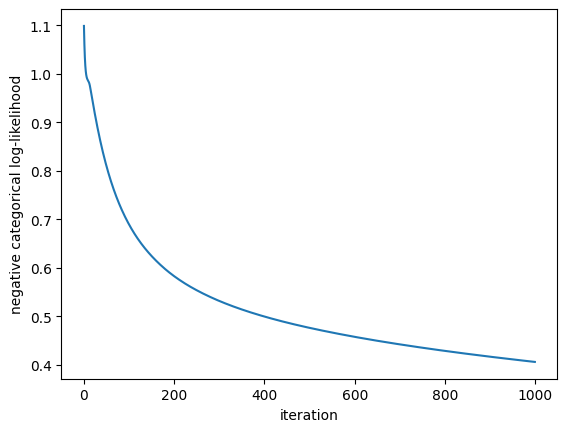

In [72]:
##### DO NOT CHANGE #####

# optimization

w0_flat = np.zeros(5 * 3) # 4 features + bias, 3 classes
w_opt_flat, loss_opt, x_history, f_x_history = \
   minimize(lambda w: objective_cat(w, train_features, oh_train_labels),
            lambda w: d_objective_cat(w, train_features, oh_train_labels),
            w0_flat, 1e-2, 1000)

w_opt = np.reshape(w_opt_flat, [5, 3])

# plotting and evaluation
print("Final Loss:", loss_opt)
plt.figure()
plt.plot(f_x_history)
plt.xlabel("iteration")
plt.ylabel("negative categorical log-likelihood")

train_pred = softmax(train_features @ w_opt)
train_acc = np.count_nonzero(np.argmax(train_pred, axis=-1) == np.argmax(oh_train_labels, axis=-1))
train_acc /= train_labels.shape[0]
test_pred = softmax(test_features @ w_opt)
test_acc = np.count_nonzero(np.argmax(test_pred, axis=-1) == np.argmax(oh_test_labels, axis=-1))
test_acc /= test_labels.shape[0]
print("Train Accuracy:", train_acc, "Test Accuracy:", test_acc)

##### DO NOT CHANGE #####

## 2.) Kernels and Kernel Ridge Regression (7 Points)

Good feature representations can make linear models much more expressive, but explicitly constructing rich feature maps can quickly become expensive. Kernel methods address this by computing inner products in an implicit feature space through a kernel function

$$
k(\boldsymbol{x}, \boldsymbol{x}') = \langle \phi(\boldsymbol{x}), \phi(\boldsymbol{x}') \rangle,
$$

without explicitly constructing the feature vectors $\phi(\boldsymbol{x})$.

In this task, we first implement Gaussian kernels and then use them for Kernel Ridge Regression.

Workflow:
- Load and plot the data
- Implement a function to compute Gaussian kernel vectors
- Implement a function to compute the Gaussian kernel matrix
- Implement Kernel Ridge Regression predictions
- Select the best model and inspect the resulting predictions

### Load and plot data
First, let us load and plot our data. Note that in this example the test data is not corrupted by noise.


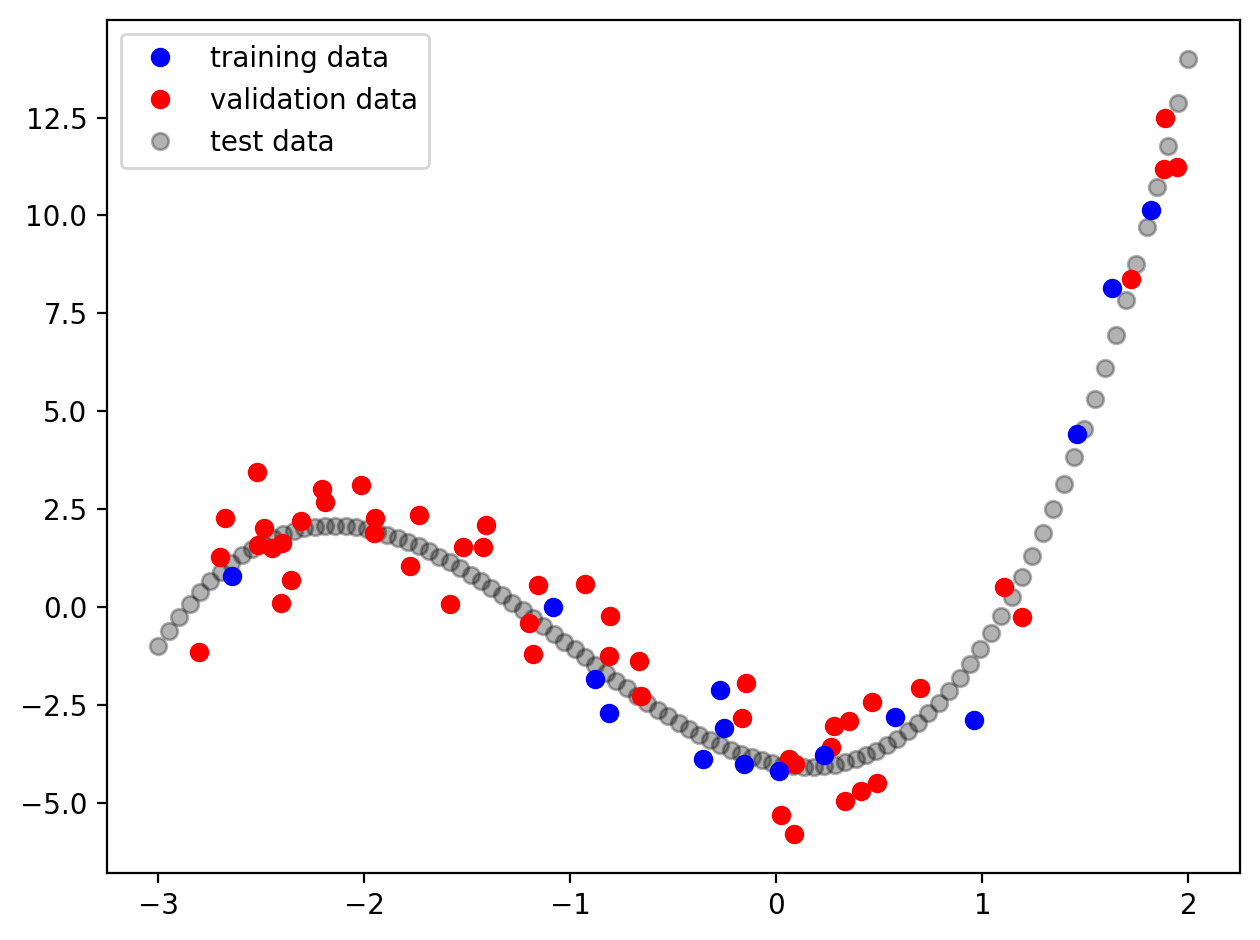

In [73]:
##### DO NOT CHANGE #####


# Set random seed to obtain reproducible results
np.random.seed(0)

# Load training, validation and test datasets
x_train = np.load('x_train.npy')
y_train = np.load('y_train.npy')

x_valid = np.load('x_valid.npy')
y_valid = np.load('y_valid.npy')

x_test = np.load('x_test.npy')
y_test = np.load('y_test.npy')

# Plot the data
plt.figure(dpi=200, tight_layout=True)
plt.plot(x_train, y_train, 'ob', label='training data', zorder=20)
plt.plot(x_valid, y_valid, 'or', label='validation data',zorder=10)
plt.plot(x_test, y_test, 'ok', label='test data', alpha=0.3, zorder=0)
plt.legend()
plt.show()


##### DO NOT CHANGE #####

### 2.1 Training, Validation and Testing Datasets (1 Point)
In this homework, we are going to use a new type of dataset "validation" to help select our best hyperparameter and avoid overfitting. Please read the explanation below and understand the roles of training, validation and testing datasets respectively.

Training, validation, and test datasets are three distinct subsets of a larger dataset that are used in the process of building and evaluating machine learning models.

The training dataset is the subset of the data that is used to train a machine learning model. In other words, it's the data that the model learns from. Typically, the training dataset makes up the majority of the available data.

The validation dataset is used to evaluate the performance of a model during the training process. It's a subset of the data that is held back from the training process and used to tune the model's hyperparameters, such as learning rate, number of hidden layers, etc. The goal of the validation dataset is to help prevent overfitting, which is when the model memorizes the training data and performs poorly on new, unseen data.

The test dataset is a completely separate subset of the data that is used to evaluate the final performance of a trained model. It represents real-world data that the model has never seen before and is used to estimate the model's accuracy on new, unseen data. The test dataset should only be used after the model has been trained and validated to prevent any bias in the evaluation.

It's important to note that the three datasets should be independent and identically distributed (IID) to ensure that the model is able to generalize well to new data. In addition, the sizes of the datasets may vary depending on the size and complexity of the original dataset and the specific requirements of the machine learning problem at hand.

(Note: In our homework, however, we are going to use a large and denoised test dataset which is for plotting convienence.)

### Gaussian Kernels

Since Gaussian kernels are among the most commonly used kernels, we will concentrate on them in this notebook. The Gaussian kernel is defined as

$$
k(\boldsymbol{x}, \boldsymbol{x}^*) = \exp\left(-\frac{\lVert\boldsymbol{x} - \boldsymbol{x}^*\rVert^2}{2\sigma^2}\right),
$$

where $\boldsymbol{x}$ and $\boldsymbol{x}^*$ are two $d$-dimensional data points. The bandwidth parameter $\sigma$ controls how quickly the similarity decreases with distance. Small values of $\sigma$ make the kernel very local, while larger values make each data point influence a wider region.

### 2.2 Kernel Vector (3 Points)

Now we implement a function to compute kernel vectors. Given $N$ training points $\boldsymbol{x}_i$, $i=1,\dots,N$, and one query point $\boldsymbol{x}^*$, the kernel vector $\boldsymbol{k}(\boldsymbol{x}^*)$ is the $N$-dimensional vector whose $i$-th element is

$$
k(\boldsymbol{x}_i, \boldsymbol{x}^*).
$$

In practice, we usually evaluate multiple query points at once. Therefore, the function below should return all corresponding kernel vectors in one matrix.

Hints:
- The computations are the same as in the Gaussian kernel formula above, but now for many pairs of inputs at once.
- Avoid using loops. You may need to add additional dimensions to the input arrays and use broadcasting.
- Numpy operations such as `np.linalg.norm()` can operate on vector inputs and take an `axis` argument.
- Make sure your code also works for data with dimension larger than 1.

In [ ]:
def get_kernel_vec(X_t: np.ndarray,
                   X_q: np.ndarray,
                   sigma: float) -> np.ndarray:
    """
    :param X_t: N training inputs (shape: [N, d])
    :param X_q: M query inputs (shape: [M, d])
    :param sigma: bandwidth of the kernel (shape: scalar)
    :return: M kernel vectors arranged as the columns of a matrix with shape [N, M]
    """

    diff = None
    diff_norm = None
    kernel_vectors = None
    
    # YOUR CODE HERE
    

    # assert the output shape being [N, M]
    assert list(kernel_vectors.shape) == [X_t.shape[0], X_q.shape[0]]
    return kernel_vectors

In [74]:
##### DO NOT CHANGE #####
# ID: test_task_2_2 - possible points: 3



##### DO NOT CHANGE #####

### Radial Basis Function (RBF) Features

We can use `get_kernel_vec()` to compute kernel vectors with respect to our training inputs, using the test inputs as query points. This allows us to visualize the kernel activations: each training data point acts like the center of a Gaussian bump, and the bandwidth parameter specifies the width of each bump.

In [ ]:
##### DO NOT CHANGE #####
# Run this block to test your code

# Compute the kernel vectors w.r.t. the training inputs, using the test inputs as query points
kernel_vectors = get_kernel_vec(x_train, x_test, 0.5)
kernel_vectors2 = get_kernel_vec(x_train, x_test, 0.2)

# Prepare plot
plt.figure(dpi=200, tight_layout=True)

# Plot the data
plt.subplot(3,1,1)
plt.plot(x_train, y_train, 'ro')
plt.plot(x_test, y_test, 'k')
plt.legend(['training data', 'ground_truth'])

# Plot the kernel vectors
plt.subplot(3,1,2)
for kernel in kernel_vectors:
    plt.plot(x_test, kernel, 'b')

plt.subplot(3,1,3)
for kernel in kernel_vectors2:
    plt.plot(x_test, kernel, 'b')
plt.show()

##### DO NOT CHANGE #####

### Kernel Ridge Regression with Gaussian Kernels

We can now perform regression using Gaussian kernels. The Kernel Ridge Regression prediction for a query point $\boldsymbol{x}^*$ is

$$
f(\boldsymbol{x}^*) = \boldsymbol{k}(\boldsymbol{x}^*)^T(\boldsymbol{K} + \lambda \boldsymbol{I})^{-1}\boldsymbol{y},
$$

where $\boldsymbol{k}(\boldsymbol{x}^*)$ is the kernel vector, $\boldsymbol{K}$ is the kernel matrix, and $\boldsymbol{y}$ contains the target values from the training data.

### 2.3 Kernel Matrix (1 Point)

The kernel matrix $\boldsymbol{K}$ contains all pairwise kernel evaluations between the training inputs:

$$
K_{ij} = k(\boldsymbol{x}_i, \boldsymbol{x}_j).
$$

Implement `get_kernel_mat` using your `get_kernel_vec` function.

In [ ]:
def get_kernel_mat(X: np.ndarray, sigma: float) -> np.ndarray:
    """
    :param X: N training inputs (shape [N, d])
    :sigma: bandwidth of the kernel (scalar)
    :return: the kernel matrix (shape [N, N])
    """
    kernel_mat = None
    # YOUR CODE HERE
    raise NotImplementedError()
    
    # assert the output shape being [N, N]
    assert list(kernel_mat.shape) == [X.shape[0], X.shape[0]]
    return kernel_mat

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_3 - possible points: 1



##### DO NOT CHANGE #####

### 2.4 Kernel Regression Prediction (2 Points)

Now that we have finished the implementation of the kernel vector $\boldsymbol{k}(\boldsymbol{x}^*)$ and the kernel matrix $\boldsymbol{K}$, we can compute the prediction $f(\boldsymbol{x}^*)$ in the function below. Here we choose a fixed ridge factor $\lambda = 10^{-3}$.

Hint: make sure you use numerically stable operations!

In [ ]:
def predict(X_t: np.ndarray, y_t: np.ndarray,
            X_q: np.ndarray, sigma: float) -> np.ndarray:
    """
    :param X_t: N training inputs (shape [N, d])
    :param y_t: N training targets (shape [N, 1])
    :param X_q: M query inputs (shape [M, d])
    :param sigma: bandwidth of the kernel (scalar)
    :return: predicted values at X_q (shape [M, 1])
    """
    k = get_kernel_vec(X_t, X_q, sigma) # shape [N, M]
    K = get_kernel_mat(X_t, sigma) # shape [N, N]
    ridge_factor = 1e-3
    
    inv_mat_train_output = None
    prediction = None

    # YOUR CODE HERE
    raise NotImplementedError()

    return prediction

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_4 - possible points: 2



##### DO NOT CHANGE #####

### Mean Squared Error

Later, for evaluation we are going to use the mean squared error to measure training, validation, and test error:

In [ ]:
##### DO NOT CHANGE #####
def mse(y_target: np.ndarray, y_pred: np.ndarray) -> float:
    """
    :param y_target: true y values
    :param y_pred: predicted y values
    :return: MSE
    """
    return np.sum((y_target-y_pred)**2)/y_pred.shape[0]

##### DO NOT CHANGE #####

## 3.) Feature-Based Support Vector Machine (Hinge Loss) (5 Points)

After seeing how kernels can be used for regression, we now return to classification and study another important loss function: the hinge loss used by support vector machines. In the lecture, SVMs can also be kernelized through their dual formulation. In this exercise, however, we use explicit cubic features rather than a kernelized SVM, so the optimization remains close to the feature-based classifiers from the previous tasks.

We will train a feature-based SVM on the two moons dataset using the hinge loss. We use the L-BFGS-B algorithm, provided by `scipy.optimize`, for the optimization. All you need to know about this optimizer is that it is gradient-based. Otherwise, you can treat it as a black box.

We load and visualize the data again. Note that we change the label for class 0 to -1.

In [ ]:
##### DO NOT CHANGE #####
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

## load data
train_data = dict(np.load("two_moons.npz", allow_pickle=True))
train_samples = train_data["samples"]
train_labels = train_data["labels"]
# we need to change the labels for class 0 to -1 to account for the different labels used by an SVM
train_labels[train_labels == 0] = -1

test_data = dict(np.load("two_moons_test.npz", allow_pickle=True))
test_samples = test_data["samples"]
test_labels = test_data["labels"]
# we need to change the labels for class 0 to -1 to account for the different labels used by an SVM
test_labels[test_labels == 0] = -1

## plot data
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.grid("on")
plt.xlim(-1.5, 2.5)
plt.ylim(-1, 1.5)
plt.title("Train Data")
plt.scatter(x=train_samples[train_labels == -1, 0], y=train_samples[train_labels == -1, 1], label="c=-1", c="blue")
plt.scatter(x=train_samples[train_labels == 1, 0], y=train_samples[train_labels == 1, 1], label="c=1", c="orange")

plt.legend()
plt.subplot(1, 2, 2)
plt.grid("on")
plt.xlim(-1.5, 2.5)
plt.ylim(-1, 1.5)
plt.title("Test Data")
plt.scatter(x=test_samples[test_labels == -1, 0], y=test_samples[test_labels == -1, 1], label="c=-1", c="blue")
plt.scatter(x=test_samples[test_labels == 1, 0], y=test_samples[test_labels == 1, 1], label="c=1", c="orange")

plt.legend()

##### DO NOT CHANGE #####

For this exercise, we use cubic features $\phi(\boldsymbol x)$. Let us define a function to compute those features.

In [ ]:
##### DO NOT CHANGE #####
def cubic_feature_fn(samples: np.ndarray) -> np.ndarray:
    """
    :param x: Batch of 2D data vectors [x, y] [N x dim]
    :return cubic features: [x**3, y**3, x**2 * y, x * y**2, x**2, y**2, x*y, x, y, 1]
    """
    x = samples[..., 0]
    y = samples[..., 1]
    return np.stack([x**3, y**3, x**2 * y, x * y**2, x**2, y**2, x*y, x, y, np.ones(x.shape[0])], axis=-1)

##### DO NOT CHANGE #####

### Exercise 3.1 (Coding): Hinge Loss Objective (2 Points)

We will implement the hinge loss objective in this exercise. It is given by

$$
\mathcal{L}_{\boldsymbol{X}, \boldsymbol{y}}(\boldsymbol{w}) = \lVert \boldsymbol{w} \rVert^2 + C \sum_i^N \max \left(0, 1 - y_i \boldsymbol{w}^T \phi(\boldsymbol{x}_i) \right),
$$

where $\boldsymbol{w}$ are our model parameters, $\phi(\boldsymbol{x})$ are our cubic features, and $y_i \in \{-1, 1\}$ are the class labels.

The following function implements the hinge loss. Fill in the missing code snippets.

In [ ]:
def objective_svm(weights: np.ndarray, features: np.ndarray, labels: np.ndarray, slack_regularizer: float) -> float:
    """
    objective for svm training with hinge loss
    :param weights: current weights to evaluate (shape: [feature_dim])
    :param features: features of training samples (shape:[N x feature_dim])
    :param labels: class labels corresponding to train samples (shape: [N])
    :param slack_regularizer: factor to weigh the violation of margin with (C in slides)
    :returns svm (hinge) objective (shape: scalar)
    """
    predictions = None
    hinge_loss = None
    reg_loss = None

    # YOUR CODE HERE
    raise NotImplementedError()

    return reg_loss + slack_regularizer * hinge_loss

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_3_1 - possible points: 2



##### DO NOT CHANGE #####

### Exercise 3.2 (Theory): Hinge Loss Gradient Derivation (Not Graded)

Derive the gradient for the hinge loss objective stated above. For all non-differentiable points in the loss curves, you can use any valid subgradient.

### Exercise 3.3 (Multiple-Choice): Hinge Loss vs. Logistic Loss (1 Point)

Both logistic regression and support vector machines can be used for binary classification, but they use different loss functions. Which statement is correct?

- a) Logistic loss penalizes all samples depending on their predicted probability, while hinge loss becomes zero for samples that are correctly classified with margin at least \(1\).
- b) Hinge loss is only defined for probabilistic classifiers that output values between \(0\) and \(1\).
- c) Logistic loss becomes exactly zero as soon as a sample is correctly classified.
- d) Hinge loss and logistic loss are identical after replacing labels \(0,1\) with labels \(-1,+1\).

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_3_3` variable.

In [ ]:
answer_3_3 = None
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_3_3 - possible points: 1

assert answer_3_3 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

### Exercise 3.4 (Coding): Hinge Loss Gradient Implementation (2 Points)

Implement the gradient for the hinge loss objective stated above. For all non-differentiable points in the loss curves, you can use any valid subgradient.

In [ ]:
def d_objective_svm(weights: np.ndarray, features: np.ndarray, labels: np.ndarray, slack_regularizer: float) -> np.ndarray:
    """
    gradient of objective for svm training with hinge loss
    :param weights: current weights to evaluate (shape: [feature_dim])
    :param features: features of training samples (shape: [N x feature_dim])
    :param labels: class labels corresponding to train samples (shape: [N])
    :param slack_regularizer: factor to weigh the violation of margin with (C in slides)
    :returns gradient of svm objective (shape: [feature_dim])
    """
    l = None
    hinge_loss_gradient = None

    # YOUR CODE HERE
    raise NotImplementedError()

    return hinge_loss_gradient

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_3_4 - possible points: 2



##### DO NOT CHANGE #####

### Train and Evaluate
Finally, we can tie everything together and get our maximum margin classifier. Here we are using the L-BFGS-B optimizer provided by Scipy. With $C=1000$ you should end up at a training accuracy of 1 and test accuracy of 0.99, but feel free to play around with $C$.

In [ ]:
##### DO NOT CHANGE #####
feature_fn = cubic_feature_fn
C = 1000.0

## optimization (for details cf. https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html)
train_features = feature_fn(train_samples)
res = opt.minimize(
    # pass objective
    fun=lambda w: objective_svm(w, train_features, train_labels, C),
    # pass initial point
    x0=np.ones(train_features.shape[-1]),
    # pass function to evaluate gradient (in scipy.opt "jac" for jacobian)
    jac=lambda w: d_objective_svm(w, train_features, train_labels, C),
    # specify method to use
    method="l-bfgs-b"
)
print(res)
w_svm = res.x

## evaluation
test_predictions = feature_fn(test_samples) @ w_svm
train_predictions = feature_fn(train_samples) @ w_svm

predicted_train_labels = np.ones(train_predictions.shape)
predicted_train_labels[train_predictions < 0] = -1
print("Train Accuracy: ", np.count_nonzero(predicted_train_labels == train_labels) / len(train_labels))

predicted_test_labels = np.ones(test_predictions.shape)
predicted_test_labels[test_predictions < 0] = -1
print("Test Accuracy: ", np.count_nonzero(predicted_test_labels == test_labels) / len(test_labels))

## plot train, contour, decision boundary and margins
plt.figure()
plt.title("Max Margin Solution (Predictions clipped at(-5, 5))")
x_plt_range = np.arange(-1.5, 2.5, 0.01)
y_plt_range = np.arange(-1, 1.5, 0.01)
plt_grid = np.stack(np.meshgrid(x_plt_range, y_plt_range), axis=-1)
flat_plt_grid = np.reshape(plt_grid, [-1, 2])
plt_grid_shape = plt_grid.shape[:2]

pred_grid = np.reshape(feature_fn(flat_plt_grid) @ w_svm, plt_grid_shape)
pred_grid = np.clip(pred_grid, -5, 5)
#plt.contour(plt_grid[..., 0], plt_grid[..., 1], pred_grid, levels=[-1.0, 0.0, 1.0], colors=["blue", "black", "orange"])
plt.contour(plt_grid[..., 0], plt_grid[..., 1], pred_grid, levels=[-1, 0, 1], colors=('blue', 'black', 'orange'),
            linestyles=('-',), linewidths=(2,))
plt.contourf(plt_grid[..., 0], plt_grid[..., 1], pred_grid, levels=10)

plt.colorbar()

s0 =plt.scatter(x=train_samples[train_labels == -1, 0], y=train_samples[train_labels == -1, 1], label="c=-1", c="blue")
s1 =plt.scatter(x=train_samples[train_labels == 1, 0], y=train_samples[train_labels == 1, 1], label="c=1", c="orange")
plt.legend()

plt.xlim(-1.5, 2.5)
plt.ylim(-1, 1.5)
plt.show()

##### DO NOT CHANGE #####

## 4.) Model Selection for Kernel Ridge Regression (1 Point)

The Gaussian kernel method introduces a hyperparameter, the bandwidth $\sigma$. We determine its value via model selection. Here, we use the hold-out method: we try different $\sigma$ values and select the model that performs best on the validation dataset.


In [ ]:
##### DO NOT CHANGE #####
sigmas = [0.01, .1, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]

# compute train and validation errors for the different sigma values
train_errors = []
validate_errors = []
for sigma in sigmas:
    predict_train = predict(X_t=x_train, y_t=y_train,
                              X_q=x_train, sigma=sigma)
    predict_valid = predict(X_t=x_train, y_t=y_train,
                             X_q=x_valid, sigma=sigma)
    train_errors.append(mse(y_train, predict_train))
    validate_errors.append(mse(y_valid, predict_valid))

# determine best model
min_valid_error_index = validate_errors.index(min(validate_errors))
print(f'minimum validation error for sigma = {sigmas[min_valid_error_index]:.2f}')

# plot the errors
x_axis = [str(x) for x in sigmas]
error_plot = plt.figure(dpi=200, tight_layout=True)
plt.plot(x_axis, train_errors, 'b')
plt.plot(x_axis, validate_errors, 'r')
plt.plot(x_axis[min_valid_error_index], validate_errors[min_valid_error_index], 'gx')
plt.xlabel( "$\sigma$")
plt.ylabel( "MSE" )
plt.legend(['train error', 'validation error','min error'])

##### DO NOT CHANGE #####

The plot above shows how the training and validation errors change for different bandwidth values $\sigma$. The green marker indicates the bandwidth with the lowest validation error among the tested values.


Let's look at predictions for different $ \sigma $ values.

In [ ]:
##### DO NOT CHANGE #####
# plot predictions for various bandwidth parameters
for sigma in [5.0,  3.0, 1.0 , 0.1]:
    # compute predictions on train, test, and validation sets
    y_pred_train = predict(X_t=x_train, y_t=y_train, X_q=x_train, sigma=sigma)
    y_pred_valid = predict(X_t=x_train, y_t=y_train, X_q=x_valid, sigma=sigma)
    y_pred_test = predict(X_t=x_train, y_t=y_train, X_q=x_test, sigma=sigma)

    # print MSEs
    print(f'sigma = {sigma:.2f}')
    print(f'MSE train: {mse(y_train, y_pred_train):.2f}')
    print(f'MSE valid: {mse(y_valid, y_pred_valid):.2f}')
    print(f'MSE test : {mse(y_test, y_pred_test):.2f}')

    # plot predictions
    sigma_fig = plt.figure(dpi=75, tight_layout=True)
    plt.plot(x_train, y_train, 'ro')
    plt.plot(x_test, y_test, 'k')
    plt.plot(x_test, y_pred_test, 'y')
    plt.legend(['Training data', 'Ground-truth', '$\sigma$ =' + str(sigma)])
    plt.show()

##### DO NOT CHANGE #####

### Exercise 4.1 (Multiple-Choice): Model Selection with Gaussian Kernels (1 Point)

Inspect the training and validation errors above, together with the predictions for different bandwidth values. Which conclusion is most appropriate?

- a) Very small bandwidth values such as $\sigma = 0.1$ underfit, because each prediction averages over almost all training samples.
- b) Very small bandwidth values can overfit because the kernel becomes highly local, while very large bandwidth values can underfit because the prediction becomes too smooth; the best choice is selected by the minimum validation error.
- c) The bandwidth should be chosen by minimizing the training error, because the training set is the only dataset used to fit the model.
- d) Larger bandwidth values always improve kernel ridge regression, because they make all training samples more relevant for every query point.

In the next cell, write your answer as a Python string with a single lowercase letter in the `answer_4_1` variable.


In [ ]:
answer_4_1 = None
# YOUR CODE HERE
raise NotImplementedError()


In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_4_1 - possible points: 1

assert answer_4_1 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####